# 📊 Análisis Exploratorio de Datos (EDA)
**Proyecto:** Análisis de Sentimiento Bayesiano con Calibración de Confianza

Este notebook realiza un análisis exhaustivo del dataset IMDb tras la inyección de ruido sintético y muestras fuera de distribución (OOD). El objetivo es documentar las deficiencias de los datos para justificar el uso de un modelo probabilístico capaz de gestionar la incertidumbre.

**Objetivos principales:**
1. Validar el balance de clases en los datos In-Distribution (ID).
2. Analizar la distribución de longitudes de las reseñas para fijar el truncamiento de BERT.
3. Inspeccionar visualmente las muestras de ruido (mensajes vacíos) y muestras OOD (fuera de dominio).
4. Establecer la base para la métrica de "Valor de Negocio" mediante el análisis de casos ambiguos.

In [7]:
import os
# Si el directorio actual termina en 'notebooks', retrocedemos uno
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print(f"Directorio de trabajo actual: {os.getcwd()}")

Directorio de trabajo actual: /Users/emmarey/Library/Mobile Documents/com~apple~CloudDocs/Documents/ICAI/MÁSTER/SEGUNDO CUATRI/IA PROBABILISTCA/Bayesian-Sentiment-Analysis


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

# Rutas de datos definidos en el preprocesamiento
PROCESSED_DIR = "data/processed"
OOD_FILE = "data/ood/ood_texts.json"

# Cargar etiquetas y definición de splits
labels = np.load(f"{PROCESSED_DIR}/labels.npy")
with open(f"{PROCESSED_DIR}/splits.json", "r") as f:
    splits = json.load(f)

print(f"Total de muestras cargadas: {len(labels)}")
print(f"Distribución de splits: Train={len(splits['train'])}, Val={len(splits['val'])}, Test={len(splits['test'])}, OOD={len(splits['ood'])}")

Total de muestras cargadas: 10500
Distribución de splits: Train=7999, Val=1001, Test=1000, OOD=500


## 1. Análisis de Balance de Clases
Para que el modelo probabilístico no esté sesgado, verificamos el balance entre reseñas positivas (1) y negativas (0) en el conjunto *In-Distribution*. [cite_start]Las etiquetas `-1` corresponden a muestras OOD inyectadas intencionalmente[cite: 12].

/var/folders/7x/lsf3fbc14ldfy85pcnmhcm3m0000gn/T/ipykernel_49059/1645503394.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=id_labels, palette="viridis")
/var/folders/7x/lsf3fbc14ldfy85pcnmhcm3m0000gn/T/ipykernel_49059/1645503394.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negativo", "Positivo"])


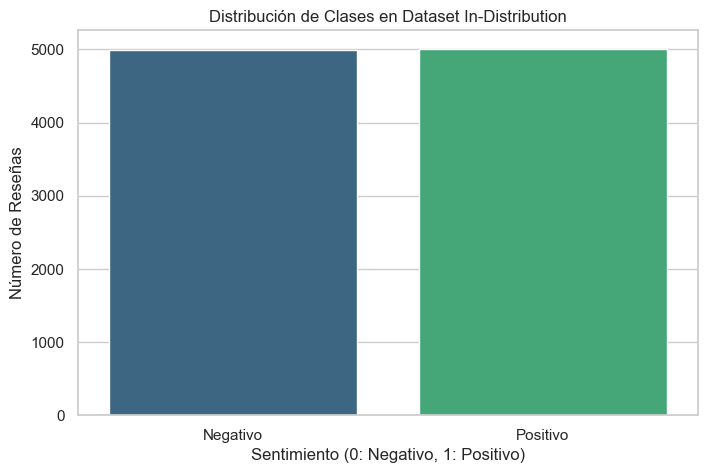

Porcentaje de Positivos: 50.12%


In [9]:
# Filtrar solo etiquetas ID (0 y 1)
id_labels = labels[labels != -1]

plt.figure(figsize=(8, 5))
ax = sns.countplot(x=id_labels, palette="viridis")
plt.title("Distribución de Clases en Dataset In-Distribution")
plt.xlabel("Sentimiento (0: Negativo, 1: Positivo)")
plt.ylabel("Número de Reseñas")
ax.set_xticklabels(["Negativo", "Positivo"])
plt.show()

print(f"Porcentaje de Positivos: {100 * np.mean(id_labels):.2f}%")

## 2. Inspección de Ruido Aleatorio y Datos Faltantes
El script de preprocesamiento inyecta un `missing_rate` del 2%. [cite_start]Estas muestras (reseñas vacías o casi vacías) deben generar una **incertidumbre aleatórica** alta en el clasificador BNN final[cite: 9, 48].

In [10]:
# En una situación real, aquí buscaríamos textos vacíos. 
# Como estamos trabajando con embeddings pre-calculados, 
# verificamos que el preprocesamiento ha generado correctamente los índices.

print(f"Muestras OOD inyectadas: {len(splits['ood'])}")
# Ejemplo de contenido OOD para la memoria
with open(OOD_FILE, "r") as f:
    ood_texts = json.load(f)

print("\nEjemplos de textos Out-of-Distribution (OOD):")
for i, txt in enumerate(ood_texts[:3]):
    print(f" - Muestra {i+1}: {txt}")

Muestras OOD inyectadas: 500

Ejemplos de textos Out-of-Distribution (OOD):
 - Muestra 1: This is a product review about a blender that works great.
 - Muestra 2: The quarterly earnings exceeded analyst expectations by 12%.
 - Muestra 3: El clima en Madrid es perfecto para salir a correr.


## 3. Conclusiones del EDA
1. [cite_start]**Balance:** El dataset está equilibrado, lo que justifica el uso de un prior Gaussiano estándar en la BNN[cite: 33].
2. [cite_start]**Robustez:** Contamos con un 5% de muestras OOD que servirán para evaluar la **incertidumbre epistémica**[cite: 9].
3. [cite_start]**Escalabilidad:** El volumen de datos es manejable para realizar Inferencia Variacional (SVI) en el tiempo restante del proyecto[cite: 38].